In [5]:
# Copyright (c) Facebook, Inc. and its affiliates. All Rights Reserved
import argparse
import datetime
import json



import random
import time
from pathlib import Path
from os import path
import os, sys
from typing import Optional

from utils.logger import setup_logger

import numpy as np
import torch
from torch.utils.data import DataLoader, DistributedSampler
import torch.distributed as dist

import utils.misc as utils
from models.dino.datasets import build_dataset, get_coco_api_from_dataset
from models.dino.engine import evaluate, train_one_epoch
from utils.utils import clean_state_dict

import matplotlib.pyplot as plt
import torchvision

In [15]:
# COCO classes
from utils.mapper import ToothLabelMapper

mapper = ToothLabelMapper()
# Skip index 0 (background), so start from 1
CLASSES = list(map(lambda x: str(x), range(1, 33)))
coco_idx_to_label = {idx: mapper.index_to_label[idx] for idx in range(1, 33)}
print("coco_idx_to_label", coco_idx_to_label)
print("CLASSES", CLASSES)

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

coco_idx_to_label {1: 18, 2: 17, 3: 16, 4: 15, 5: 14, 6: 13, 7: 12, 8: 11, 9: 1, 10: 2, 11: 3, 12: 4, 13: 5, 14: 6, 15: 7, 16: 8, 17: 38, 18: 37, 19: 36, 20: 35, 21: 34, 22: 33, 23: 32, 24: 31, 25: 21, 26: 22, 27: 23, 28: 24, 29: 25, 30: 26, 31: 27, 32: 28}
CLASSES ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32']


In [7]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        Returns:
            Tensor: Normalized image.
        """
        output_tensor = []
        for t, m, s in zip(tensor, self.mean, self.std):
            output_tensor.append(t.mul(s).add(m))
            # t.mul_(s).add_(m)
            # The normalize code -> t.sub_(m).div_(s)
        return torch.stack(output_tensor, dim=0)

unnorm = UnNormalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

# for output bounding box post-processing
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

def plot_results(img, labels, boxes, mask=None):
    h, w = img.shape[1:]
    if mask != None:
        # width
        if torch.where(mask[0])[0].shape[0] > 0:
            mask_w = torch.where(mask[0])[0][0]
            w = min(w, mask_w)
        if torch.where(mask[:, 0])[0].shape[0]:
            mask_h = torch.where(mask[:, 0])[0][0]
            h = min(h, mask_h)
            
    boxes = rescale_bboxes(boxes, (w, h))
    plt.figure(figsize=(16,10))
    unimage = unnorm(img)
    #image = (unimage*256).to(torch.uint8)
    image = unimage
    pil_img = torchvision.transforms.functional.to_pil_image(image)
    plt.imshow(pil_img)
    
    ax = plt.gca()
    colors = COLORS * 100
    for label, (xmin, ymin, xmax, ymax), c in zip(labels, boxes.tolist(), colors):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        text = f'{CLASSES[label]}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

In [16]:
from argparse import Namespace
args = Namespace(config_file='models/dino/configs/DINO_4scale_cls32.py', 
                 options={'dn_scalar': 100, 'embed_init_tgt': True, 
                          'dn_label_coef': 1.0, 'dn_bbox_coef': 1.0, 'use_ema': False, 'dn_box_noise_scale': 1.0}, 
                 dataset_file='coco', coco_path='dataset/coco/dino/quadrant_enumeration', coco_panoptic_path=None, 
                 remove_difficult=False, fix_size=False, output_dir='checkpoints/dino/whatever', note='', device='cuda', seed=42, resume='', 
                 pretrain_model_path=None, finetune_ignore=None, start_epoch=0, eval=False, num_workers=10, test=False, debug=False, 
                 find_unused_params=False, save_results=False, save_log=False, world_size=1, dist_url='env://', rank=0, local_rank=0, 
                 amp=False, distributed=False, data_aug_scales=[480, 512, 544, 576, 608, 640, 672, 704, 736, 768, 800], data_aug_max_size=1333, 
                 data_aug_scales2_resize=[400, 500, 600], data_aug_scales2_crop=[384, 600], data_aug_scale_overlap=None, num_classes=32, lr=0.0001, 
                 param_dict_type='default', lr_backbone=1e-05, lr_backbone_names=['backbone.0'], lr_linear_proj_names=['reference_points', 'sampling_offsets'], 
                 lr_linear_proj_mult=0.1, ddetr_lr_param=False, batch_size=2, weight_decay=0.0001, epochs=12, lr_drop=11, save_checkpoint_interval=1, 
                 clip_max_norm=0.1, onecyclelr=False, multi_step_lr=False, lr_drop_list=[33, 45], modelname='dino', frozen_weights=None, 
                 backbone='resnet50', use_checkpoint=False, dilation=False, position_embedding='sine', pe_temperatureH=20, pe_temperatureW=20, 
                 return_interm_indices=[1, 2, 3], backbone_freeze_keywords=None, enc_layers=6, dec_layers=6, unic_layers=0, pre_norm=False, 
                 dim_feedforward=2048, hidden_dim=256, dropout=0.0, nheads=8, num_queries=900, query_dim=4, num_patterns=0, 
                 pdetr3_bbox_embed_diff_each_layer=False, pdetr3_refHW=-1, random_refpoints_xy=False, fix_refpoints_hw=-1, 
                 dabdetr_yolo_like_anchor_update=False, dabdetr_deformable_encoder=False, dabdetr_deformable_decoder=False, 
                 use_deformable_box_attn=False, box_attn_type='roi_align', dec_layer_number=None, num_feature_levels=4, enc_n_points=4, 
                 dec_n_points=4, decoder_layer_noise=False, dln_xy_noise=0.2, dln_hw_noise=0.2, add_channel_attention=False, add_pos_value=False, 
                 two_stage_type='standard', two_stage_pat_embed=0, two_stage_add_query_num=0, two_stage_bbox_embed_share=False, 
                 two_stage_class_embed_share=False, two_stage_learn_wh=False, two_stage_default_hw=0.05, two_stage_keep_all_tokens=False, 
                 num_select=300, transformer_activation='relu', batch_norm_type='FrozenBatchNorm2d', masks=False, aux_loss=True, 
                 set_cost_class=2.0, set_cost_bbox=5.0, set_cost_giou=2.0, cls_loss_coef=1.0, mask_loss_coef=1.0, dice_loss_coef=1.0, 
                 bbox_loss_coef=5.0, giou_loss_coef=2.0, enc_loss_coef=1.0, interm_loss_coef=1.0, no_interm_box_loss=False, focal_alpha=0.25, 
                 decoder_sa_type='sa', matcher_type='HungarianMatcher', decoder_module_seq=['sa', 'ca', 'ffn'], nms_iou_threshold=-1, 
                 dec_pred_bbox_embed_share=True, dec_pred_class_embed_share=True, use_dn=True, dn_number=100, dn_box_noise_scale=1.0, 
                 dn_label_noise_ratio=0.5, embed_init_tgt=True, dn_labelbook_size=91, match_unstable_error=True,
                 use_detached_boxes_dec_out=False, dn_scalar=100, dn_label_coef=1.0, dn_bbox_coef=1.0)

In [17]:
seed = args.seed + utils.get_rank()
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [18]:
dataset_train = build_dataset(image_set='train', args=args)

data_aug_params: {
  "scales": [
    480,
    512,
    544,
    576,
    608,
    640,
    672,
    704,
    736,
    768,
    800
  ],
  "max_size": 1333,
  "scales2_resize": [
    400,
    500,
    600
  ],
  "scales2_crop": [
    384,
    600
  ]
}
loading annotations into memory...
Done (t=0.10s)
creating index...
index created!


In [19]:
print(len(dataset_train[0]))
print(dataset_train[0][0].shape)
print(dataset_train[1][0].shape)
dataset_train[0][1]

2
torch.Size([3, 512, 1054])
torch.Size([3, 480, 646])


{'boxes': tensor([[0.5080, 0.4485, 0.0369, 0.1991],
         [0.5405, 0.4503, 0.0335, 0.2012],
         [0.5717, 0.4584, 0.0441, 0.2301],
         [0.6303, 0.4732, 0.0642, 0.2371],
         [0.6629, 0.4886, 0.0673, 0.2413],
         [0.7043, 0.4858, 0.0530, 0.2202],
         [0.7489, 0.4774, 0.0526, 0.1935],
         [0.4731, 0.4447, 0.0369, 0.2040],
         [0.4366, 0.4433, 0.0369, 0.1872],
         [0.4005, 0.4436, 0.0509, 0.2357],
         [0.3780, 0.4749, 0.0393, 0.1942],
         [0.3314, 0.4897, 0.0656, 0.2308],
         [0.2868, 0.4823, 0.0475, 0.2329],
         [0.2473, 0.4908, 0.0465, 0.2090],
         [0.4813, 0.6663, 0.0273, 0.2153],
         [0.4566, 0.6494, 0.0290, 0.1942],
         [0.4303, 0.7022, 0.0366, 0.2857],
         [0.3766, 0.7029, 0.0536, 0.2561],
         [0.3079, 0.7092, 0.0981, 0.2125],
         [0.2678, 0.6736, 0.0806, 0.1655],
         [0.5021, 0.6560, 0.0266, 0.1882],
         [0.5230, 0.6576, 0.0314, 0.1990],
         [0.5462, 0.6982, 0.0395, 0.2734],
  

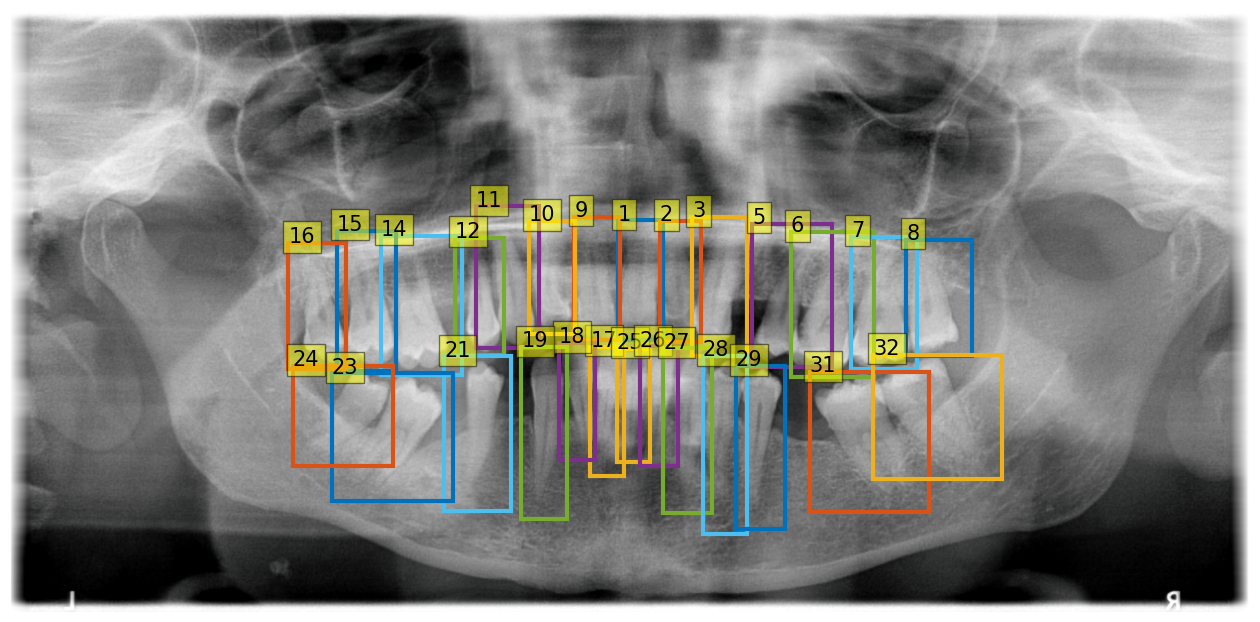

In [58]:
example = dataset_train[0]
plot_results(example[0], example[1]["labels"], example[1]["boxes"])

In [36]:
sampler_train = torch.utils.data.RandomSampler(dataset_train)
batch_sampler_train = torch.utils.data.BatchSampler(
        sampler_train, args.batch_size, drop_last=True)

data_loader_train = DataLoader(dataset_train, batch_sampler=batch_sampler_train,
                                   collate_fn=utils.collate_fn, num_workers=args.num_workers)

In [37]:
i = 0
for samples, targets in data_loader_train:
    i += 1
    if i > 2:
        break
samples.tensors.shape

torch.Size([2, 3, 609, 1333])

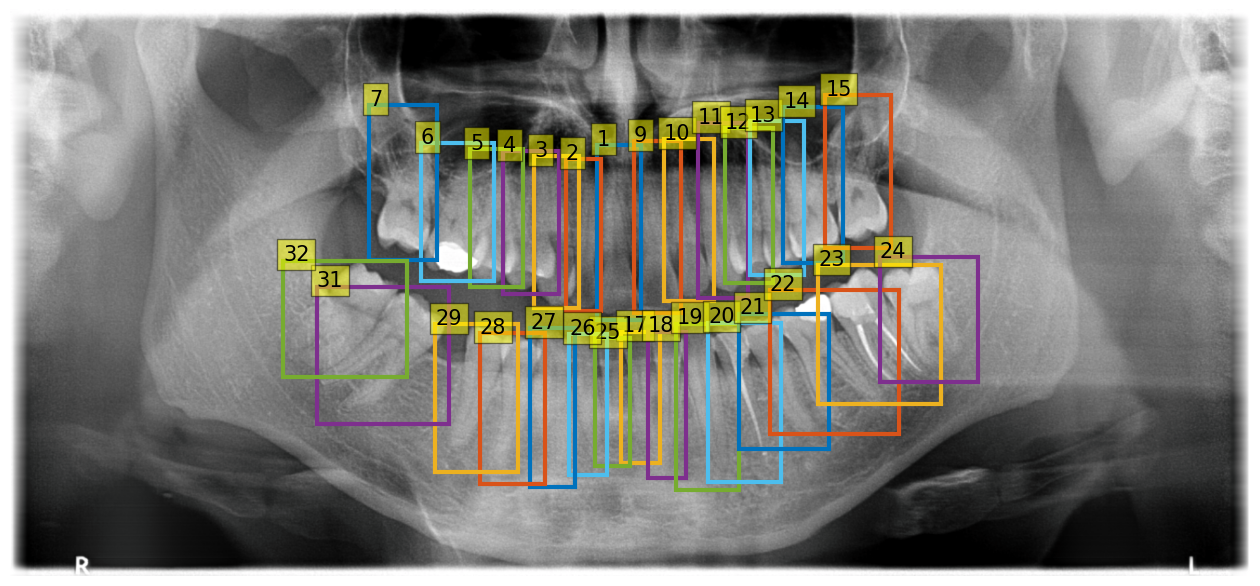

In [48]:
plot_results(samples.tensors[0], targets[0]["labels"], targets[0]["boxes"], mask=samples.mask[0])

In [81]:
def build_model_main(args):
    # we use register to maintain models from catdet6 on.
    from models.dino.registry import MODULE_BUILD_FUNCS
    assert args.modelname in MODULE_BUILD_FUNCS._module_dict
    build_func = MODULE_BUILD_FUNCS.get(args.modelname)
    model, criterion, postprocessors = build_func(args)
    return model, criterion, postprocessors

model, criterion, postprocessors = build_model_main(args)

In [82]:
device = "cuda"
model = model.to(device)

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 23.54 GiB of which 15.75 MiB is free. Process 2002571 has 23.52 GiB memory in use. Of the allocated memory 22.94 GiB is allocated by PyTorch, and 132.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [62]:
samples = samples.to(device)
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

In [75]:
outputs = model(samples, targets)
outputs

OutOfMemoryError: CUDA out of memory. Tried to allocate 100.00 MiB. GPU 0 has a total capacity of 23.54 GiB of which 55.75 MiB is free. Process 2002571 has 23.48 GiB memory in use. Of the allocated memory 22.82 GiB is allocated by PyTorch, and 218.78 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [80]:
import torch
torch.cuda.empty_cache()
torch.cuda.ipc_collect()


In [64]:
loss_dict = criterion(outputs, targets)